# Tier 3 Post-Processing — Demonstration on Synthetic Data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/noelv-09/phd-ch1-marsh-suitability/blob/main/notebooks/tier3_demo.ipynb)


**Author:** Noelani Villa · **Repository:** [phd-ch1-marsh-suitability](https://github.com/noelv-09/phd-ch1-marsh-suitability) · **Status:** demonstration notebook (synthetic data only)

---

## Purpose

This notebook demonstrates the **Tier 3** post-processing pipeline described in Chapter 1 of the dissertation —
EOF decomposition + k-means clustering on phase-resolved hydrodynamic output — using a **synthetic
tidal channel domain** instead of the real D-Flow FM simulations. It is meant to make the *method* legible to
a reader who cannot yet see the full pipeline code (which runs on the Auburn Easley HPC cluster and will be
released after committee review).

## What this notebook is not

- **Not real model output.** The velocity, shear stress, and elevation fields below are analytically generated
  from a sinusoidal tide over an idealised channel/marsh cross-section. They mimic the *structure* of
  D-Flow FM output (`FlowFM_map.nc` variables `mesh2d_s1`, `mesh2d_ucx/ucy`, `mesh2d_taus`) but carry no
  site interpretation.
- **Not the production pipeline.** The real Chapter 1 workflow uses NetCDF loaders, mesh-aware processing,
  a controlled bathymetry generator, sensitivity sweeps across 21 scenarios, and multiple diagnostic families
  (ebb-residual streamlines, drain-window platform fraction, boundary-buffer checks, etc.). This notebook
  isolates only the EOF + clustering + Tier-1-vs-Tier-3 comparison at demonstration scale.
- **Not a scientific result.** The T1/T3 disagreement statistics reported at the end are properties of the
  toy data, not of any real restoration site.

## Method in one paragraph

Chapter 1 asks how engineered tidal channel geometry shapes phase-resolved low-energy habitat and drainage
patterns in restored marshes. Conventional (Tier 1) suitability maps threshold *tidally-averaged* velocity
and shear against literature values; that averaging can misrepresent the intermittent low-energy windows
during which pioneer salt-marsh seeds actually settle. Tier 3 replaces the temporal average with an
**EOF decomposition** of the shear-stress field followed by **k-means clustering** of the leading principal
components, isolating discrete *slack-water states* whose spatial pattern is then thresholded. The two
classifications are compared with over-call percentage and Cohen's κ so bulk area, per-cell precision, and
chance-corrected agreement are reported together rather than a single statistic dominating.

> **What to look for at the end.** Tier 3 flags **more** suitable area than Tier 1 in this demo, which is
> the direction the phase-resolved framing is meant to expose: Tier 1 misses cells that are quiescent during
> the low-energy slack windows but energetic enough during peak flow to fail the time-averaged threshold.
> The absolute numbers here are properties of the toy field; the qualitative behaviour — T3 recovering
> cells that time-averaging washes out — is the whole point of the pipeline.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import cohen_kappa_score

rng = np.random.default_rng(seed=42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
print("Environment ready.")

Environment ready.


## 1. Synthetic domain

A 50 × 50 idealised plan-view of a tidal marsh with a single meandering channel running roughly north-south.
Grid spacing 5 m (250 × 250 m domain). The channel cross-section carries higher velocities and shear; the
marsh platform to either side experiences intermittent inundation.

Following the Chapter 1 convention, we synthesise the fields to *look like* D-Flow FM's cell-centered
output on an unstructured mesh, but here on a regular grid for simplicity.

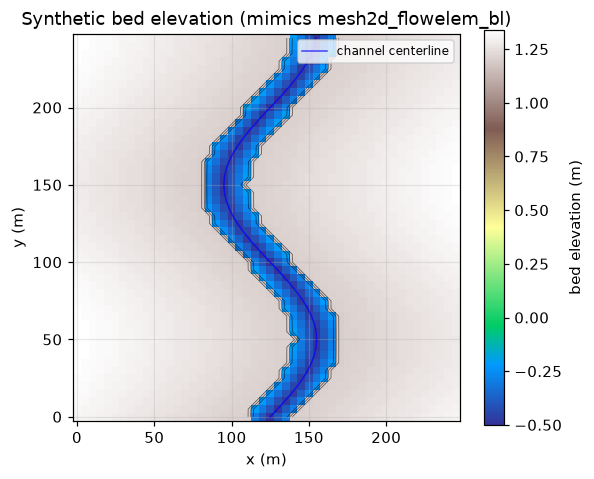

In [2]:
nx, ny = 50, 50
dx = 5.0  # metres
x = np.arange(nx) * dx
y = np.arange(ny) * dx
X, Y = np.meshgrid(x, y)

# Meandering channel centerline: gentle sine wave around x = 125 m
channel_x = 125.0 + 30.0 * np.sin(2 * np.pi * y / 200.0)
dist_to_channel = np.abs(X - channel_x[:, None])  # (ny, nx)

# Bed elevation: channel invert at -0.5 m, sloping up to +1.2 m marsh platform (bare marsh ~ MHW - 0.1 m)
channel_mask = dist_to_channel < 15.0
platform_mask = ~channel_mask
bed_elev = np.where(
    channel_mask,
    -0.5 + 0.02 * dist_to_channel,
    1.2 + 0.001 * (dist_to_channel - 15.0),
)

fig, ax = plt.subplots(1, 1, figsize=(5.5, 5))
im = ax.pcolormesh(X, Y, bed_elev, cmap="terrain", shading="auto")
ax.contour(X, Y, bed_elev, levels=[0.0, 0.5, 1.0], colors="k", linewidths=0.5, alpha=0.6)
ax.plot(channel_x, y, "b-", linewidth=1.0, alpha=0.7, label="channel centerline")
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Synthetic bed elevation (mimics mesh2d_flowelem_bl)")
plt.colorbar(im, ax=ax, label="bed elevation (m)", shrink=0.8)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 2. Synthetic tidal forcing

Mixed semidiurnal-ish tide: M2 (period 12.42 h, amplitude 1.0 m) + S2 (period 12.00 h, amplitude 0.3 m) over
48 hours at 15-min resolution — 193 timesteps. Real Chapter 1 runs use ~72 h at 10-min resolution forced with
Skagit Bay tidal boundary conditions.

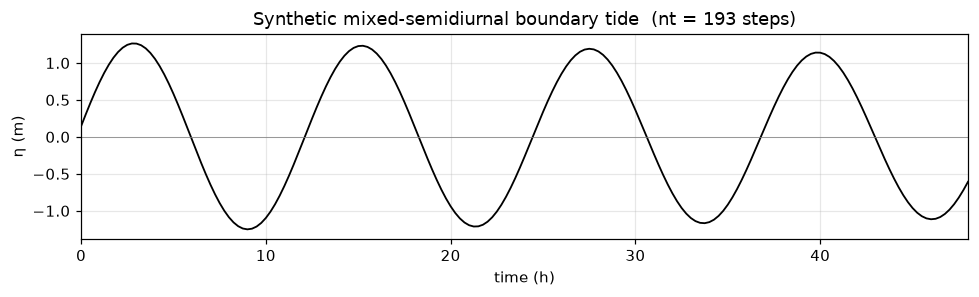

In [3]:
dt = 15 * 60  # seconds
duration = 48 * 3600
t = np.arange(0, duration + dt, dt)
nt = len(t)
t_hr = t / 3600.0

T_M2 = 12.42 * 3600
T_S2 = 12.00 * 3600
eta = 1.0 * np.sin(2 * np.pi * t / T_M2) + 0.3 * np.sin(2 * np.pi * t / T_S2 + 0.5)

fig, ax = plt.subplots(1, 1, figsize=(9, 2.8))
ax.plot(t_hr, eta, "k-", linewidth=1.2)
ax.axhline(0.0, color="grey", linewidth=0.5)
ax.set_xlabel("time (h)")
ax.set_ylabel("η (m)")
ax.set_title(f"Synthetic mixed-semidiurnal boundary tide  (nt = {nt} steps)")
ax.set_xlim(0, t_hr[-1])
plt.tight_layout()
plt.show()

## 3. Synthesise phase-resolved fields

For each timestep, compute water depth (elevation − bed), depth-averaged velocity magnitude, and bed shear
stress. Velocity is largest during flood and ebb peaks, smallest at slacks. Marsh cells are only wet when
η exceeds their bed level.

Formulas are deliberately simple — this is a demo, not a hydrodynamic solver. The real T3 pipeline
consumes `mesh2d_s1`, `mesh2d_ucx/ucy`, and `mesh2d_taus` from D-Flow FM directly.

In [4]:
# Depth: (nt, ny, nx)
depth = np.maximum(eta[:, None, None] - bed_elev[None, :, :], 0.0)
wet = depth > 0.02  # 2 cm wet threshold

# Velocity magnitude proxy: |dη/dt| * amplification in channel, damped on marsh.
# Use centered differences so endpoints don't spike. Scale factor calibrated so
# channel flood/ebb peaks reach ~0.5 m/s and marsh cells ~0.08 m/s.
d_eta_dt = np.gradient(eta, dt)
# Zero the endpoints to avoid spurious "peaks" at t=0 and t=end
d_eta_dt[0] = d_eta_dt[1]
d_eta_dt[-1] = d_eta_dt[-2]
# Flood/ebb asymmetry: flood spreads across the marsh (positive dη/dt),
# ebb concentrates back into the channel (negative dη/dt). This makes PC1 and PC2
# span a meaningful 2D space instead of one dominant mode.
is_flood = (d_eta_dt > 0)[:, None, None]  # (nt, 1, 1)
# In flood, marsh amplification is higher (sheet flow across platform).
# In ebb, channel concentration is stronger.
flood_amp = np.where(channel_mask, 0.9, 0.25)[None, :, :]
ebb_amp = np.where(channel_mask, 1.15, 0.10)[None, :, :]
in_channel_amp = np.where(is_flood, flood_amp, ebb_amp)
speed = np.abs(d_eta_dt)[:, None, None] * 3000.0 * in_channel_amp
speed = speed * wet  # zero on dry cells

# Bed shear stress (Manning-like): τ = ρ·g·n²·U²/h^(1/3), with n = 0.03
rho = 1025.0
g = 9.81
n_man = 0.03
h_safe = np.where(depth > 0.05, depth, 0.05)
taus = rho * g * n_man**2 * speed**2 / (h_safe ** (1.0 / 3.0))
taus = taus * wet

# Quick sanity: channel speed and shear at flood peak
flood_peak = int(np.argmax(d_eta_dt))
print(f"Flood-peak timestep: t = {t_hr[flood_peak]:.2f} h")
print(f"Channel-averaged speed at flood peak: {speed[flood_peak][channel_mask].mean():.3f} m/s")
print(f"Channel-averaged shear at flood peak: {taus[flood_peak][channel_mask].mean():.3f} Pa")
print(f"Domain-max speed across simulation:   {speed.max():.3f} m/s")

Flood-peak timestep: t = 12.00 h
Channel-averaged speed at flood peak: 0.473 m/s
Channel-averaged shear at flood peak: 3.148 Pa
Domain-max speed across simulation:   0.613 m/s


## 4. Snapshots at four representative phases

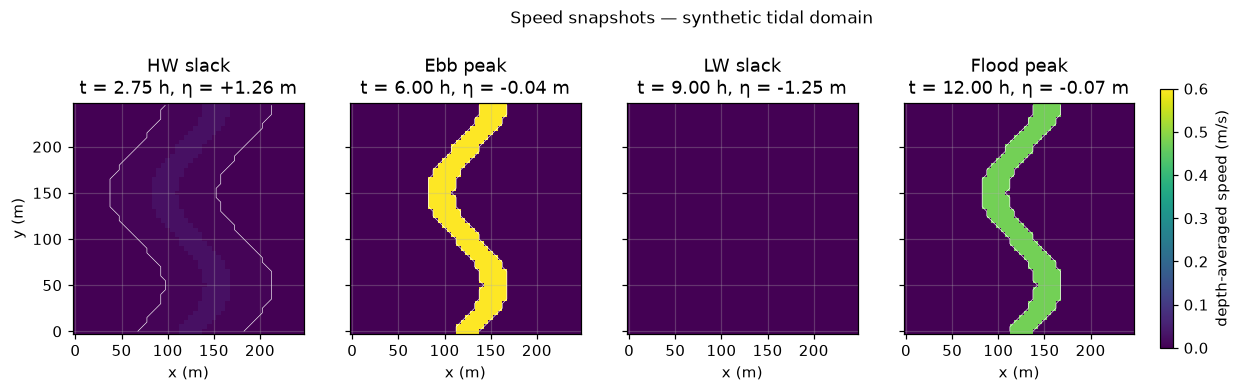

In [5]:
phases = {
    "HW slack": int(np.argmax(eta)),
    "Ebb peak": int(np.argmin(d_eta_dt)),
    "LW slack": int(np.argmin(eta)),
    "Flood peak": int(np.argmax(d_eta_dt)),
}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True, sharey=True)
for ax, (label, k) in zip(axes, phases.items()):
    im = ax.pcolormesh(X, Y, speed[k], cmap="viridis", shading="auto", vmin=0, vmax=0.6)
    ax.contour(X, Y, wet[k].astype(float), levels=[0.5], colors="w", linewidths=0.4)
    ax.set_aspect("equal")
    ax.set_title(f"{label}\nt = {t_hr[k]:.2f} h, η = {eta[k]:+.2f} m")
    ax.set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
fig.colorbar(im, ax=axes, label="depth-averaged speed (m/s)", shrink=0.85, pad=0.02)
plt.suptitle("Speed snapshots — synthetic tidal domain", y=1.02, fontsize=11)
plt.show()

## 5. EOF decomposition of the shear-stress field

Reshape `taus(nt, ny, nx)` → `taus_flat(nt, ncells)`, standardise each cell (zero mean, unit variance across
time), then take the SVD. This is the *empirical orthogonal function* decomposition: left singular vectors
give the temporal principal components (PCs), right singular vectors give the spatial modes.

The real Chapter 1 pipeline masks to wet-any cells, weights by cell area, and validates cluster-count
stability. Here we keep it minimal.

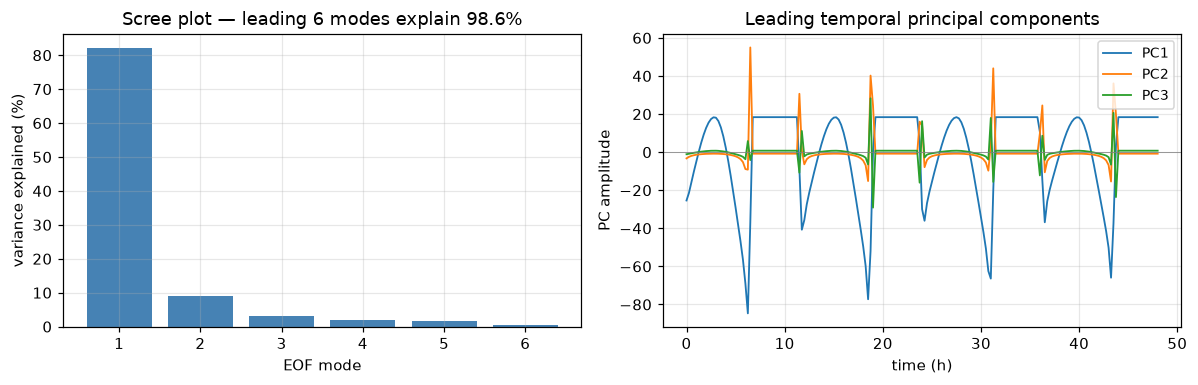

In [6]:
wet_ever = wet.any(axis=0)  # (ny, nx) cells wet at least once
taus_flat = taus.reshape(nt, -1)  # (nt, ncells)
wet_any = wet_ever.flatten()
X_active = taus_flat[:, wet_any]

# Center by removing the time-mean per cell (do NOT standardise by std, so magnitude matters).
# This is the convention used in the Chapter 1 pipeline: EOFs of the centered shear anomaly.
mu = X_active.mean(axis=0)
X_std = X_active - mu

# SVD (thin)
U, s, Vt = np.linalg.svd(X_std, full_matrices=False)
var_frac = s**2 / np.sum(s**2)
PCs = U * s  # temporal principal components, shape (nt, k_modes)

n_show = 6
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(np.arange(1, n_show + 1), var_frac[:n_show] * 100, color="steelblue")
axes[0].set_xlabel("EOF mode")
axes[0].set_ylabel("variance explained (%)")
axes[0].set_title(f"Scree plot — leading {n_show} modes explain {var_frac[:n_show].sum() * 100:.1f}%")

for i in range(3):
    axes[1].plot(t_hr, PCs[:, i], label=f"PC{i + 1}", linewidth=1.2)
axes[1].axhline(0.0, color="grey", linewidth=0.5)
axes[1].set_xlabel("time (h)")
axes[1].set_ylabel("PC amplitude")
axes[1].set_title("Leading temporal principal components")
axes[1].legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 6. K-means clustering on PC space → hydrodynamic states

Cluster each timestep by its position in the leading-2 PC space. In Chapter 1 the slack state is
operationalised as the subset of hydrodynamic conditions with the lowest domain-mean kinetic energy — for
a mixed semidiurnal tide this typically resolves into an HW-slack and an LW-slack cluster. Here we take
the two lowest-mean-speed clusters as the T3 slack state; the real Chapter 1 pipeline additionally
validates cluster-count stability across k ∈ {4, 5, 6, 7}.

Cluster mean channel-region speeds: [0.116 0.011 0.144 0.064 0.135 0.08 ]
Slack clusters (T3 state): [np.int64(1), np.int64(3)]


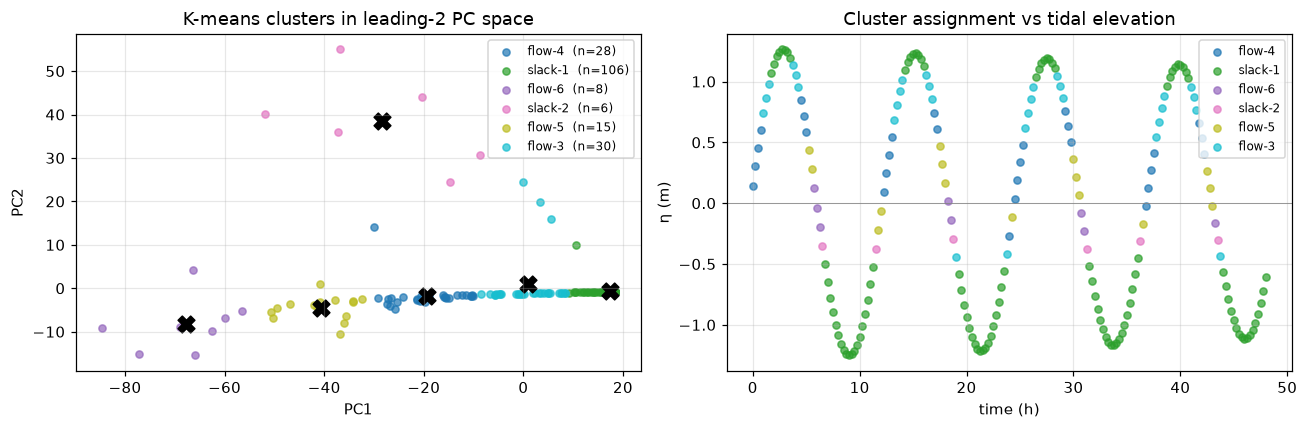

T3 slack state = clusters [np.int64(1), np.int64(3)]
  112 of 193 timesteps (58.0%)
  Slack timestep range: 1.75 h – 48.00 h


In [7]:
n_clusters = 6
km = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
labels = km.fit_predict(PCs[:, :2])
centroids = km.cluster_centers_

# Identify slack-state clusters. In Chapter 1 the slack state is the set of
# hydrodynamic conditions where near-bed velocities and shear are compatible with
# pioneer salt-marsh seed settlement. Here we take the two lowest-mean-speed
# clusters (HW-slack and LW-slack analogues) as the T3 slack state.
cluster_mean_speed = np.array(
    [(speed[labels == i].mean(axis=0) * wet_ever).sum() / max(wet_ever.sum(), 1)
     for i in range(n_clusters)]
)
sorted_by_speed = np.argsort(cluster_mean_speed)
slack_clusters = list(sorted_by_speed[:2])  # two lowest-energy clusters
slack_idx = slack_clusters[0]  # canonical slack cluster (for compat with figures)
print(f"Cluster mean channel-region speeds: {cluster_mean_speed.round(3)}")
print(f"Slack clusters (T3 state): {slack_clusters}")

cluster_names = {}
for rank, idx in enumerate(sorted_by_speed):
    if idx in slack_clusters:
        cluster_names[idx] = f"slack-{rank + 1}"
    else:
        cluster_names[idx] = f"flow-{rank + 1}"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_c = plt.cm.tab10(np.linspace(0, 1, n_clusters))
for i in range(n_clusters):
    mask = labels == i
    axes[0].scatter(
        PCs[mask, 0],
        PCs[mask, 1],
        s=22,
        color=colors_c[i],
        alpha=0.7,
        label=f"{cluster_names[i]}  (n={mask.sum()})",
    )
    axes[0].scatter(centroids[i, 0], centroids[i, 1], marker="X", s=120, color="black")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("K-means clusters in leading-2 PC space")
axes[0].legend(loc="best", fontsize=8)

for i in range(n_clusters):
    mask = labels == i
    axes[1].scatter(t_hr[mask], eta[mask], s=22, color=colors_c[i], alpha=0.7, label=cluster_names[i])
axes[1].axhline(0.0, color="grey", linewidth=0.5)
axes[1].set_xlabel("time (h)")
axes[1].set_ylabel("η (m)")
axes[1].set_title("Cluster assignment vs tidal elevation")
axes[1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

slack_mask_all = np.isin(labels, slack_clusters)
slack_times = t_hr[slack_mask_all]
print(f"T3 slack state = clusters {slack_clusters}")
print(f"  {slack_mask_all.sum()} of {nt} timesteps ({slack_mask_all.mean() * 100:.1f}%)")
if slack_times.size:
    print(f"  Slack timestep range: {slack_times.min():.2f} h – {slack_times.max():.2f} h")

## 7. Tier 1 vs Tier 3 suitability maps

**Tier 1** — average velocity and shear across the whole simulation, threshold against literature values
for pioneer salt-marsh seed settlement (`v_thr = 0.10 m/s`, `τ_thr = 0.10 Pa`). A cell is suitable if
BOTH averaged velocity AND averaged shear are below threshold AND the cell is wet.

**Tier 3** — average velocity and shear across only the *slack-cluster* timesteps, apply the same
thresholds. Cells wet during slack that also fall below the low-energy thresholds are counted suitable.

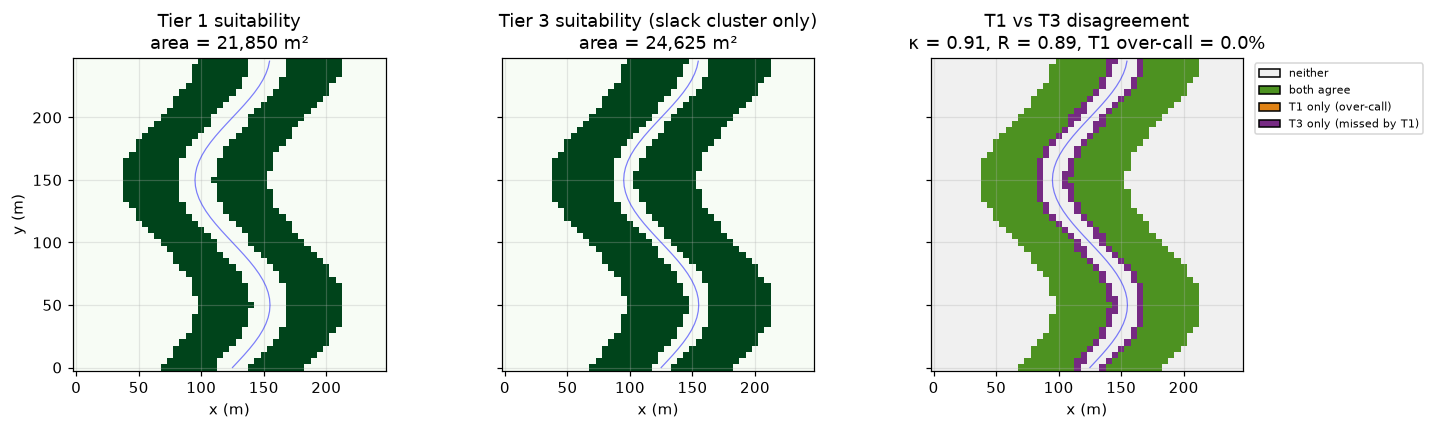

In [8]:
# Thresholds calibrated for the SYNTHETIC demo (bare-marsh literature values for
# pioneer seed settlement are v ~ 0.05–0.1 m/s, tau ~ 0.05–0.1 Pa on real sites;
# scaled up here so the demo produces visible T1–T3 disagreement).
v_thr = 0.15  # m/s
tau_thr = 0.40  # Pa

def mean_when_wet(field, wet_arr):
    """Time-average of `field(t, y, x)` restricted to timesteps where the cell is wet."""
    n_wet = wet_arr.sum(axis=0).clip(min=1)
    return (field * wet_arr).sum(axis=0) / n_wet

# Tier 1 — average across ALL wet timesteps
speed_T1 = mean_when_wet(speed, wet)
taus_T1 = mean_when_wet(taus, wet)
suit_T1 = (speed_T1 < v_thr) & (taus_T1 < tau_thr) & wet_ever

# Tier 3 — restrict to slack-state timesteps only
slack_mask = np.isin(labels, slack_clusters)
speed_T3 = mean_when_wet(speed[slack_mask], wet[slack_mask])
taus_T3 = mean_when_wet(taus[slack_mask], wet[slack_mask])
wet_slack = wet[slack_mask].any(axis=0)
suit_T3 = (speed_T3 < v_thr) & (taus_T3 < tau_thr) & wet_slack

area_cell = dx * dx
area_T1 = suit_T1.sum() * area_cell
area_T3 = suit_T3.sum() * area_cell

# Disagreement metrics
both = suit_T1 & suit_T3
t1_only = suit_T1 & ~suit_T3
t3_only = suit_T3 & ~suit_T1
overcall_pct = t1_only.sum() / max(suit_T3.sum(), 1) * 100.0
kappa = cohen_kappa_score(suit_T1.flatten(), suit_T3.flatten())
ratio_T1_T3 = area_T1 / max(area_T3, 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
axes[0].pcolormesh(X, Y, suit_T1.astype(float), cmap="Greens", vmin=0, vmax=1, shading="auto")
axes[0].set_title(f"Tier 1 suitability\narea = {area_T1:,.0f} m²")
axes[1].pcolormesh(X, Y, suit_T3.astype(float), cmap="Greens", vmin=0, vmax=1, shading="auto")
axes[1].set_title(f"Tier 3 suitability (slack cluster only)\narea = {area_T3:,.0f} m²")

disagreement = np.zeros_like(suit_T1, dtype=int)
disagreement[both] = 1
disagreement[t1_only] = 2
disagreement[t3_only] = 3
from matplotlib.colors import ListedColormap
cmap_d = ListedColormap(["#f0f0f0", "#4d9221", "#e08214", "#762a83"])
im = axes[2].pcolormesh(X, Y, disagreement, cmap=cmap_d, vmin=0, vmax=3, shading="auto")
axes[2].set_title(
    f"T1 vs T3 disagreement\nκ = {kappa:.2f}, R = {ratio_T1_T3:.2f}, T1 over-call = {overcall_pct:.1f}%"
)

for ax in axes:
    ax.plot(channel_x, y, "b-", linewidth=0.8, alpha=0.5)
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="#f0f0f0", edgecolor="k", label="neither"),
    Patch(facecolor="#4d9221", edgecolor="k", label="both agree"),
    Patch(facecolor="#e08214", edgecolor="k", label="T1 only (over-call)"),
    Patch(facecolor="#762a83", edgecolor="k", label="T3 only (missed by T1)"),
]
axes[2].legend(handles=legend_els, loc="upper left", fontsize=7, bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 8. Reporting triple

Chapter 1 uses three complementary statistics rather than a single number so bulk area, per-cell precision,
and chance-corrected agreement are reported together:

In [9]:
print("=" * 60)
print("Reporting triple  (synthetic-data demonstration)")
print("=" * 60)
print(f"  R (T1 area / T3 area) . . . . . . . {ratio_T1_T3:.3f}")
print(f"  T1 over-call percentage . . . . . . {overcall_pct:.1f} %")
print(f"  Cohen's kappa (T1 vs T3) . . . . .  {kappa:.3f}")
print()
print(f"  Tier 1 suitable area . . . . . . .  {area_T1:>10,.0f} m²")
print(f"  Tier 3 suitable area . . . . . . .  {area_T3:>10,.0f} m²")
print(f"  Domain wet-ever area . . . . . . .  {wet_ever.sum() * area_cell:>10,.0f} m²")
print("=" * 60)
print()
print("Interpretation caveat:")
print("  These numbers describe the SYNTHETIC domain only. Tier 3 flags MORE")
print("  suitable area than Tier 1 here, which is the direction the phase-resolved")
print("  framing is designed to reveal: Tier 1 misses cells that are quiescent")
print("  during slack windows but energetic during peak flow, so tidal averaging")
print("  pushes them above the suitability threshold. Real Chapter 1 results on")
print("  21 D-Flow FM scenarios show the same qualitative behaviour, with T3")
print("  area peaking near ~297,582 m² at N=4 channels and declining as channel")
print("  count grows further.")


Reporting triple  (synthetic-data demonstration)
  R (T1 area / T3 area) . . . . . . . 0.887
  T1 over-call percentage . . . . . . 0.0 %
  Cohen's kappa (T1 vs T3) . . . . .  0.905

  Tier 1 suitable area . . . . . . .      21,850 m²
  Tier 3 suitable area . . . . . . .      24,625 m²
  Domain wet-ever area . . . . . . .      29,250 m²

Interpretation caveat:
  These numbers describe the SYNTHETIC domain only. Tier 3 flags MORE
  suitable area than Tier 1 here, which is the direction the phase-resolved
  framing is designed to reveal: Tier 1 misses cells that are quiescent
  during slack windows but energetic during peak flow, so tidal averaging
  pushes them above the suitability threshold. Real Chapter 1 results on
  21 D-Flow FM scenarios show the same qualitative behaviour, with T3
  area peaking near ~297,582 m² at N=4 channels and declining as channel
  count grows further.


## Next steps in the real pipeline

What this demo intentionally omits, and where each piece lives in the full Chapter 1 workflow:

| Piece | Where it lives |
| --- | --- |
| NetCDF loaders (`mesh2d_s1`, `mesh2d_ucx/ucy`, `mesh2d_taus`) | `src/io_utils.py` |
| Controlled `.xyz` bathymetry generator (2:1 side slopes, tapered inverts) | Easley scratch workspace |
| 21-scenario sweep with sensitivity across side slope, cluster count, thresholds | `src/cli.py` → `run_all_scenarios.sh` |
| Ebb-residual streamlines & drain-window platform fraction (v6 diagnostics) | `src/diagnostics.py` |
| Bathymetry QC guardrail (finite `mesh2d_node_z`, non-flat `mesh2d_flowelem_bl`) | pre-analysis check |
| Restoration Coherence Ratio (RCR) & Ecological Persistence Index (EPI) | `src/rcr.py`, `src/epi.py` |
| Consolidated metrics table `combined_master_metrics_v6.csv` (21 rows × 274 cols) | Easley `results_all/` |

The full pipeline runs on Auburn Easley HPC with SLURM job chains submitted via `run_all_scenarios.sh`.
Code migration into this repository follows the committee review and manuscript-submission timeline.